# Dasar-Dasar Klasifikasi dalam Machine Learning

Notebook ini berisi penjelasan komprehensif mengenai dasar-dasar klasifikasi, komponen utama, alur kerja, contoh dataset tiruan, hingga implementasi kode visualisasi untuk memahami bagaimana model memisahkan data berdasarkan kelasnya.

## 1. Apa itu Klasifikasi?

**Klasifikasi** adalah salah satu teknik utama dalam *Supervised Learning* (pembelajaran terawasi) di mana tujuannya adalah untuk memprediksi label atau kategori diskrit (kelas) dari suatu data berdasarkan fitur-fitur yang dimiliki.

Contoh populer:
- **Biner (2 Kelas):** Deteksi Spam (Spam vs. Bukan Spam), Diagnosis Penyakit (Sakit vs. Sehat).
- **Multi-kelas (>2 Kelas):** Klasifikasi jenis buah (Apel, Jeruk, Pisang), Pengenalan angka tulisan tangan (0 sampai 9).

## 2. Pembuatan Contoh Dataset: Prediksi Bermain Tenis

Mari kita buat contoh dataset sederhana yang sering digunakan untuk mempelajari dasar klasifikasi cuaca terhadap keputusan bermain tenis.

In [77]:
import pandas as pd
import numpy as np

# Membuat dataset tiruan untuk simulasi
data_random = {
    'Hari': [f'Day {i}' for i in range(1, 31)], # ditambah menjadi 30 hari
    'Outlook': ['Sunny', 'Rainy', 'Overcast', 'Sunny', 'Overcast', 'Rainy', 'Sunny', 'Rainy', 'Overcast', 'Sunny', 'Rainy', 'Overcast', 'Sunny', 'Rainy', 'Overcast', 'Sunny', 'Rainy', 'Overcast', 'Sunny', 'Overcast', 'Rainy', 'Sunny', 'Rainy', 'Overcast', 'Sunny', 'Rainy', 'Overcast', 'Sunny', 'Rainy', 'Overcast'],
    'Temperature': [25, 28, 30, 27, 32, 31, 20, 26, 28, 33, 30, 31, 32, 27, 35, 29, 29, 30, 31, 26, 32, 33, 29, 27, 30, 31, 28, 32, 30, 27], # ditambah menjadi 30 hari
    # humidity unitnya adalah persentase
    'Humidity': [20, 36, 60, 0, 90, 25, 26, 50, 40, 58, 56, 50, 65, 77, 90, 90, 50, 88, 78, 50, 90, 100, 99, 90, 98, 98, 95, 57, 90, 50],
    'Windy': [False, True, False, False, True, True, True, False, False, True, False, True, False, True, True, False, True, False, False, True, True, True, False, False, True, False, True, False, True, True],
    'Play': ['No', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No']
}

# Membuat DataFrame dari dataset tiruan dan menampilkan isinya
df = pd.DataFrame(data_random)
df

,Hari,Outlook,Temperature,Humidity,Windy,Play
0,Day 1,Sunny,25,20,False,No
1,Day 2,Rainy,28,36,True,Yes
2,Day 3,Overcast,30,60,False,Yes
3,Day 4,Sunny,27,0,False,Yes
4,Day 5,Overcast,32,90,True,No
5,Day 6,Rainy,31,25,True,No
6,Day 7,Sunny,20,26,True,Yes
7,Day 8,Rainy,26,50,False,Yes
8,Day 9,Overcast,28,40,False,Yes
9,Day 10,Sunny,33,58,True,No


Dalam tabel di atas:
- **Fitur (Features):** `Outlook`, `Temperature`, `Humidity`, `Windy` (Variabel independen yang memengaruhi hasil).
- **Target / Label:** `Play` (Variabel dependen diskrit berupa kategori 'Yes' atau 'No' yang ingin diprediksi).

## 3. Visualisasi Konsep Dasar Klasifikasi (*Decision Boundary*)

Secara visual, tugas algoritma klasifikasi pada data numerik kontinyu adalah menemukan garis atau ruang pembatas (**Decision Boundary**) yang secara optimal dapat memisahkan titik-titik data dari kelas yang berbeda.

Di bawah ini adalah simulasi pembuatan data 2 Dimensi (2 Fitur) dengan 2 Kelas menggunakan Scikit-Learn untuk melihat bagaimana garis pembatas keputusan itu bekerja.

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier


# 2. Proses Encoding: Mengubah Teks menjadi Angka Numerik
# Kita buat mapping manual agar nilainya konsisten
outlook_map = {'Sunny': 0, 'Overcast': 1, 'Rainy': 2}
# temp_map = {'Cool': 0, 'Mild': 1, 'Hot': 2}
play_map = {'No': 0, 'Yes': 1}
# humidity_map = {'High': 0, 'Normal': 1}

df['Outlook_Num'] = df['Outlook'].map(outlook_map)
# df['Temp_Num'] = df['Temperature'].map(temp_map)
df['Play_Num'] = df['Play'].map(play_map)
# df['Humidity_Num'] = df['Humidity'].map(humidity_map)

df

,Hari,Outlook,Temperature,Humidity,Windy,Play,Outlook_Num,Play_Num
0,Day 1,Sunny,25,20,False,No,0,0
1,Day 2,Rainy,28,36,True,Yes,2,1
2,Day 3,Overcast,30,60,False,Yes,1,1
3,Day 4,Sunny,27,0,False,Yes,0,1
4,Day 5,Overcast,32,90,True,No,1,0
5,Day 6,Rainy,31,25,True,No,2,0
6,Day 7,Sunny,20,26,True,Yes,0,1
7,Day 8,Rainy,26,50,False,Yes,2,1
8,Day 9,Overcast,28,40,False,Yes,1,1
9,Day 10,Sunny,33,58,True,No,0,0


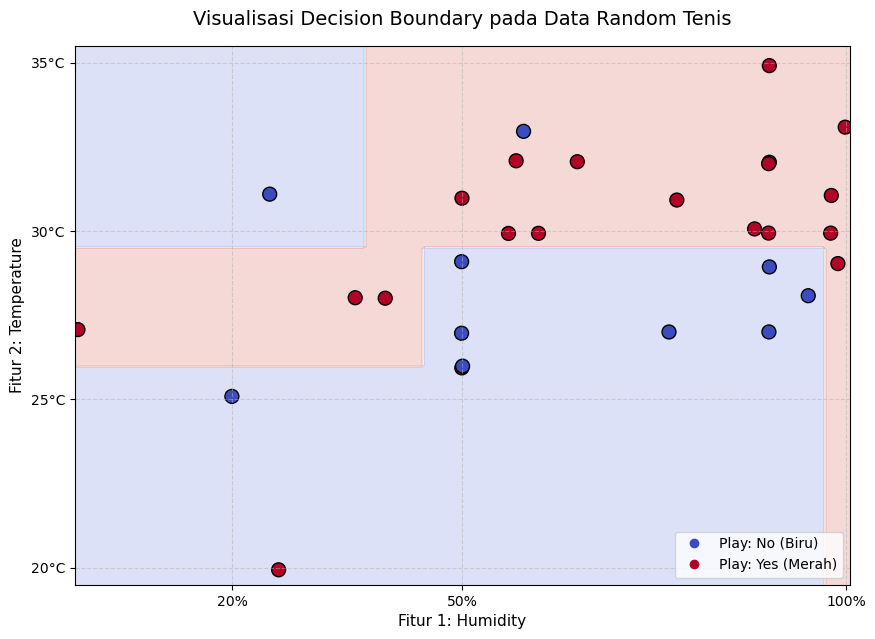

In [79]:
# Kita pilih 2 fitur numerik ini sebagai X, dan Play sebagai y
X = df[['Humidity', 'Temperature']].values
y = df['Play_Num'].values

# 3. Inisialisasi dan latih model classifier Decision Tree
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X, y)

# 4. Membuat grid mesh untuk menggambar area pembatas (Decision Boundary)
# Jarak min dan max disesuaikan dengan skala angka coding kita (0 sampai 2)
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

# Prediksi kelas untuk setiap titik pada grid
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# 5. Plotting Hasil Visualisasi
plt.figure(figsize=(10, 7))

# Mewarnai background area keputusan (Decision Boundary)
plt.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.coolwarm)

# Menggambar scatter plot titik data asli dengan sedikit 'jitter' (pergeseran acak) 
# agar titik yang menumpuk di angka yang sama bisa terlihat menyebar
np.random.seed(42)
X_jitter = X + np.random.uniform(-0.1, 0.1, size=X.shape)
scatter = plt.scatter(X_jitter[:, 0], X_jitter[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm, s=100)

# Pengaturan Grafis Sumbu & Label
plt.title("Visualisasi Decision Boundary pada Data Random Tenis", fontsize=14, pad=15)

# Mengubah angka di sumbu X dan Y kembali menjadi label teks agar mudah dibaca
plt.xticks(ticks=[20, 50, 100], labels=['20%', '50%', '100%'])
plt.yticks(ticks=[20, 25, 30, 35], labels=['20°C', '25°C', '30°C', '35°C'])

plt.xlabel("Fitur 1: Humidity", fontsize=11)
plt.ylabel("Fitur 2: Temperature", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Menambahkan Legenda
plt.legend(handles=scatter.legend_elements()[0], labels=['Play: No (Biru)', 'Play: Yes (Merah)'], loc="lower right")


plt.show()

## 4. Evaluasi Hasil Klasifikasi

Setelah model membagi area keputusan di atas, performa model diukur menggunakan beberapa parameter utama seperti:
1. **Accuracy:** Total prediksi benar dibagi total seluruh data.
2. **Precision:** Keakuratan model dalam memprediksi label positif.
3. **Recall / Sensitivity:** Kemampuan model dalam menemukan kembali seluruh sampel berlabel positif.

In [66]:

# --- CARA 1: MENGUJI DENGAN DATA BARU ---

# Misal kita punya data cuaca baru untuk besok:
# Cuaca: Cerah/Sunny (0), Suhu: celcius
data_besok = [[50, 27]]  # Humidity=50%, Temperature=27°C
# data_besok[0][0] = humidity_map[data_besok[0][0]]  # Ubah Humidity ke angka

# Meminta model melakukan prediksi
prediksi_besok = clf.predict(data_besok)

# Mengubah hasil prediksi angka (0 atau 1) kembali ke teks (No atau Yes)
hasil_teks = 'Yes' if prediksi_besok[0] == 1 else 'No'

print(f"Hasil Pengujian Data Baru:")
print(f"Jika Humidity=50% dan Temperature=27, Model memprediksi Play = {hasil_teks}")



Hasil Pengujian Data Baru:
Jika Humidity=50% dan Temperature=27, Model memprediksi Play = Yes


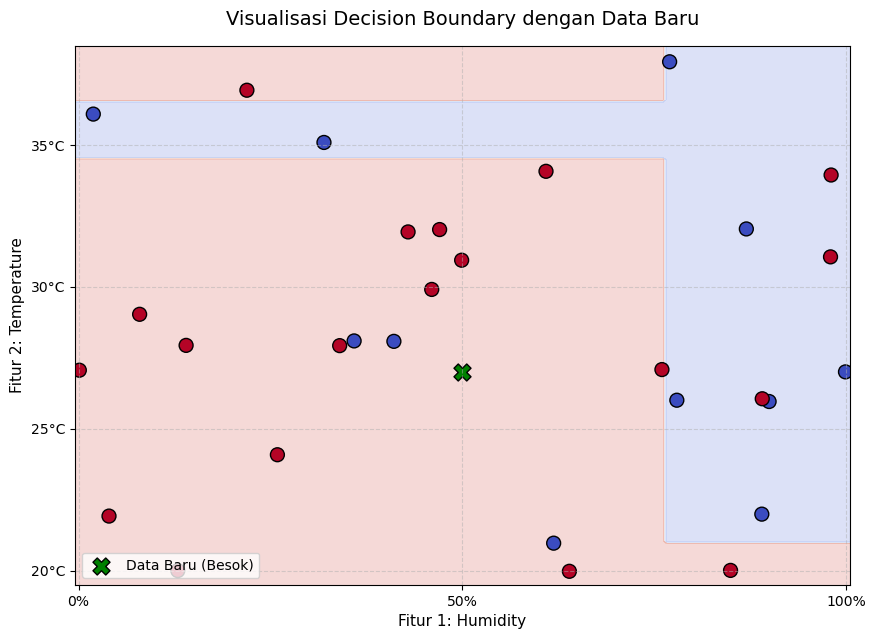

In [67]:
# tambahkan data baru ke dalam visualisasi untuk melihat di mana posisinya
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.coolwarm)
plt.scatter(X_jitter[:, 0], X_jitter[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm, s=100)
plt.scatter(data_besok[0][0], data_besok[0][1], c='green', edgecolors='k', s=150, marker='X', label='Data Baru (Besok)')
plt.title("Visualisasi Decision Boundary dengan Data Baru", fontsize=14, pad=15)
plt.xticks(ticks=[0, 50, 100], labels=['0%', '50%', '100%'])
plt.yticks(ticks=[20, 25, 30, 35], labels=['20°C', '25°C', '30°C', '35°C'])
plt.xlabel("Fitur 1: Humidity", fontsize=11)
plt.ylabel("Fitur 2: Temperature", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc="lower left")
plt.show()

In [ ]:
# Latihan: Imputasi Data Hilang
data_baru = {
    'Hari': [f'Day {i}' for i in range(1, 31)], # ditambah menjadi 30 hari
    'Outlook': ['Sunny', 'Rainy', 'Overcast', 'Sunny', 'Overcast', 'Rainy', 'Sunny', 'Rainy', 'Overcast', 'Sunny', 'Rainy', 'Overcast', 'Sunny', 'Rainy', 'Overcast', 'Sunny', 'Rainy', 'Overcast', 'Sunny', 'Overcast', 'Rainy', 'Sunny', 'Rainy', 'Overcast', 'Sunny', 'Rainy', 'Overcast', 'Sunny', 'Rainy', 'Overcast'],
    'Temperature': [25, 28, 30, 27, 32, 31, 'NA', 26, 28, 33, 30, 31, 32, 27, 31, 29, 'NA', 30, 31, 26, 32, 33, 29, 27, 30, 31, 28, 32, 30, 27], # ditambah menjadi 30 hari
    # humidity unitnya adalah persentase
    'Humidity': [20, 50, 100, 50, 100, 100, 50, 50, 50, 100, 100, 'NA', 100, 50, 100, 100, 50, 100, 100, 50, 100, 100, 50, 50, 50, 100, 100, 50, 100, 50],
    'Windy': [False, True, False, False, True, True, True, False, False, True, False, True, False, True, True, False, True, False, False, True, True, True, False, False, True, False, True, False, True, True],
    'Play': ['No', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No']
}

# Lakukan imputasi dengan mengganti 'NA' dengan nilai rata-rata untuk humidity dan median untuk temperature